<a href="https://colab.research.google.com/github/Vladzimir-40/Proj_1/blob/main/my_file6/Untitled6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

from google.colab import files
files.upload() # Загрузите файл kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vladimir401011","key":"e6b9eec8a00a0a7c2c3e5fcbd033ab06"}'}

In [4]:
import pandas as pd
import kagglehub
import os

class Data_loading:
    @staticmethod
    def load_from_kaggle(dataset_path, filename):
        """
        Загружает dataset из Kaggle используя kagglehub

        Args:
            dataset_path (str): путь к dataset на Kaggle
            filename (str): название файла для загрузки

        Returns:
            pd.DataFrame: загруженный датафрейм
        """
        download_path = kagglehub.dataset_download(dataset_path)
        file_path = os.path.join(download_path, filename)
        return pd.read_csv(file_path)

# Download latest version
path = kagglehub.dataset_download("ylmzasel/synthetic-cryptocurrency-dataset-hourly-2025")

print("Path to dataset files:", path)
print("\nЗагруженные файлы:")
for file in os.listdir(path):
    print(f"📁 {file}")

100%|██████████| 4.84M/4.84M [00:00<00:00, 157MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ylmzasel/synthetic-cryptocurrency-dataset-hourly-2025/versions/1

Загруженные файлы:
📁 sentetik_kripto_veriseti_saatlik_2025.csv


In [5]:
df = Data_loading.load_from_kaggle("ylmzasel/synthetic-cryptocurrency-dataset-hourly-2025", "sentetik_kripto_veriseti_saatlik_2025.csv")

Using Colab cache for faster access to the 'synthetic-cryptocurrency-dataset-hourly-2025' dataset.


In [6]:
df.describe()


,open,high,low,close,volume,spread,num_trades,onchain_tx_count,sentiment,exchange_net_flow,returns_1h,rolling_vol_24h,rolling_vol_7d,future_return_1h,future_return_24h
count,70080.000000,70080.000000,70080.000000,70080.000000,7.008000e+04,70080.000000,7.008000e+04,7.008000e+04,70080.000000,7.008000e+04,70076.000000,69984.000000,69408.000000,70076.000000,69984.000000
mean,24916.251455,25038.800345,24793.953900,24916.630836,1.410433e+07,5.905878,2.946678e+05,1.217957e+05,0.503654,8.651723e+03,0.000077,0.008307,0.008787,0.000077,0.001544
std,38941.498754,39130.005637,38753.233457,38942.075115,2.445142e+07,9.416331,3.487112e+05,1.449451e+05,0.211159,3.257810e+06,0.009219,0.004108,0.002670,0.009219,0.038099
min,0.515325,0.519823,0.513045,0.515325,1.054885e+03,0.000400,2.558785e+04,1.023800e+04,0.000000,-2.454505e+07,-0.178868,0.003018,0.004385,-0.178868,-0.199314
25%,101.621366,102.284975,101.172173,101.621366,1.232611e+04,0.048774,6.960839e+04,2.862225e+04,0.361862,-4.541733e+03,-0.004906,0.006119,0.006938,-0.004906,-0.023230
50%,2151.560320,2284.790951,2140.930372,2151.560320,3.579212e+05,0.788941,1.259223e+05,5.218000e+04,0.503785,1.157393e+01,0.000025,0.007651,0.008633,0.000025,0.000713
75%,28337.434326,28471.154520,28240.934790,28337.434326,1.112238e+07,8.918016,4.695658e+05,1.961660e+05,0.643382,5.361237e+03,0.005044,0.009226,0.009898,0.005044,0.025277
max,144263.660211,144694.231269,143601.226608,144263.660211,1.726006e+08,112.068387,3.462929e+06,2.451685e+06,1.000000,3.061428e+07,0.210782,0.057822,0.022370,0.210782,0.259095


In [7]:
# Просматриваем первые несколько строк датасета
print(df.head())


# Получаем общую информацию о датасете
print(df.info())

             timestamp asset      open      high       low     close  \
0  2023-09-11 09:00:00   ADA  0.879548  0.880720  0.877064  0.879548   
1  2023-09-11 10:00:00   ADA  0.879548  0.884898  0.877859  0.883065   
2  2023-09-11 11:00:00   ADA  0.883065  0.893341  0.882340  0.891826   
3  2023-09-11 12:00:00   ADA  0.891826  0.894654  0.889495  0.890054   
4  2023-09-11 13:00:00   ADA  0.890054  0.892255  0.882007  0.884310   

         volume    spread     num_trades  onchain_tx_count  sentiment  \
0  5.702945e+07  0.000488   97606.020762             39042   0.617655   
1  5.784244e+07  0.000576  102197.392312             41696   0.548247   
2  6.102497e+07  0.000585  118398.566289             49708   0.425128   
3  4.258452e+07  0.000500   87911.581387             35513   0.436492   
4  6.078514e+07  0.000471  132982.615289             54909   0.555826   

   exchange_net_flow  returns_1h  rolling_vol_24h  rolling_vol_7d  \
0       0.000000e+00         NaN              NaN          

Мы видим, что не все поля заполнены на 100%, но нехватка данных тут минимальна ~1% и не долна повлиять на обучение моделей.

0   timestamp           - временная метка

1   asset               - актив (криптовалюта)

2   open                - цена открытия

3   high                - максимальная цена

4   low                 - минимальная цена

5   close               - цена закрытия

6   volume              - объем торгов

7   spread              - спред (разница между ценой покупки и продажи)

8   num_trades          - количество сделок

9   onchain_tx_count    - количество транзакций в блокчейне

10  sentiment           - сентимент (настроения рынка)

11  exchange_net_flow   - нетто-поток на биржи

12  returns_1h          - доходность за 1 час

13  rolling_vol_24h     - скользящая волатильность за 24 часа

14  rolling_vol_7d      - скользящая волатильность за 7 дней

15  future_return_1h    - будущая доходность через 1 час (целевая ?)

16  future_return_24h   - будущая доходность через 24 часа (целевая ?)

✅ Данные ADA за неделю: 168 записей


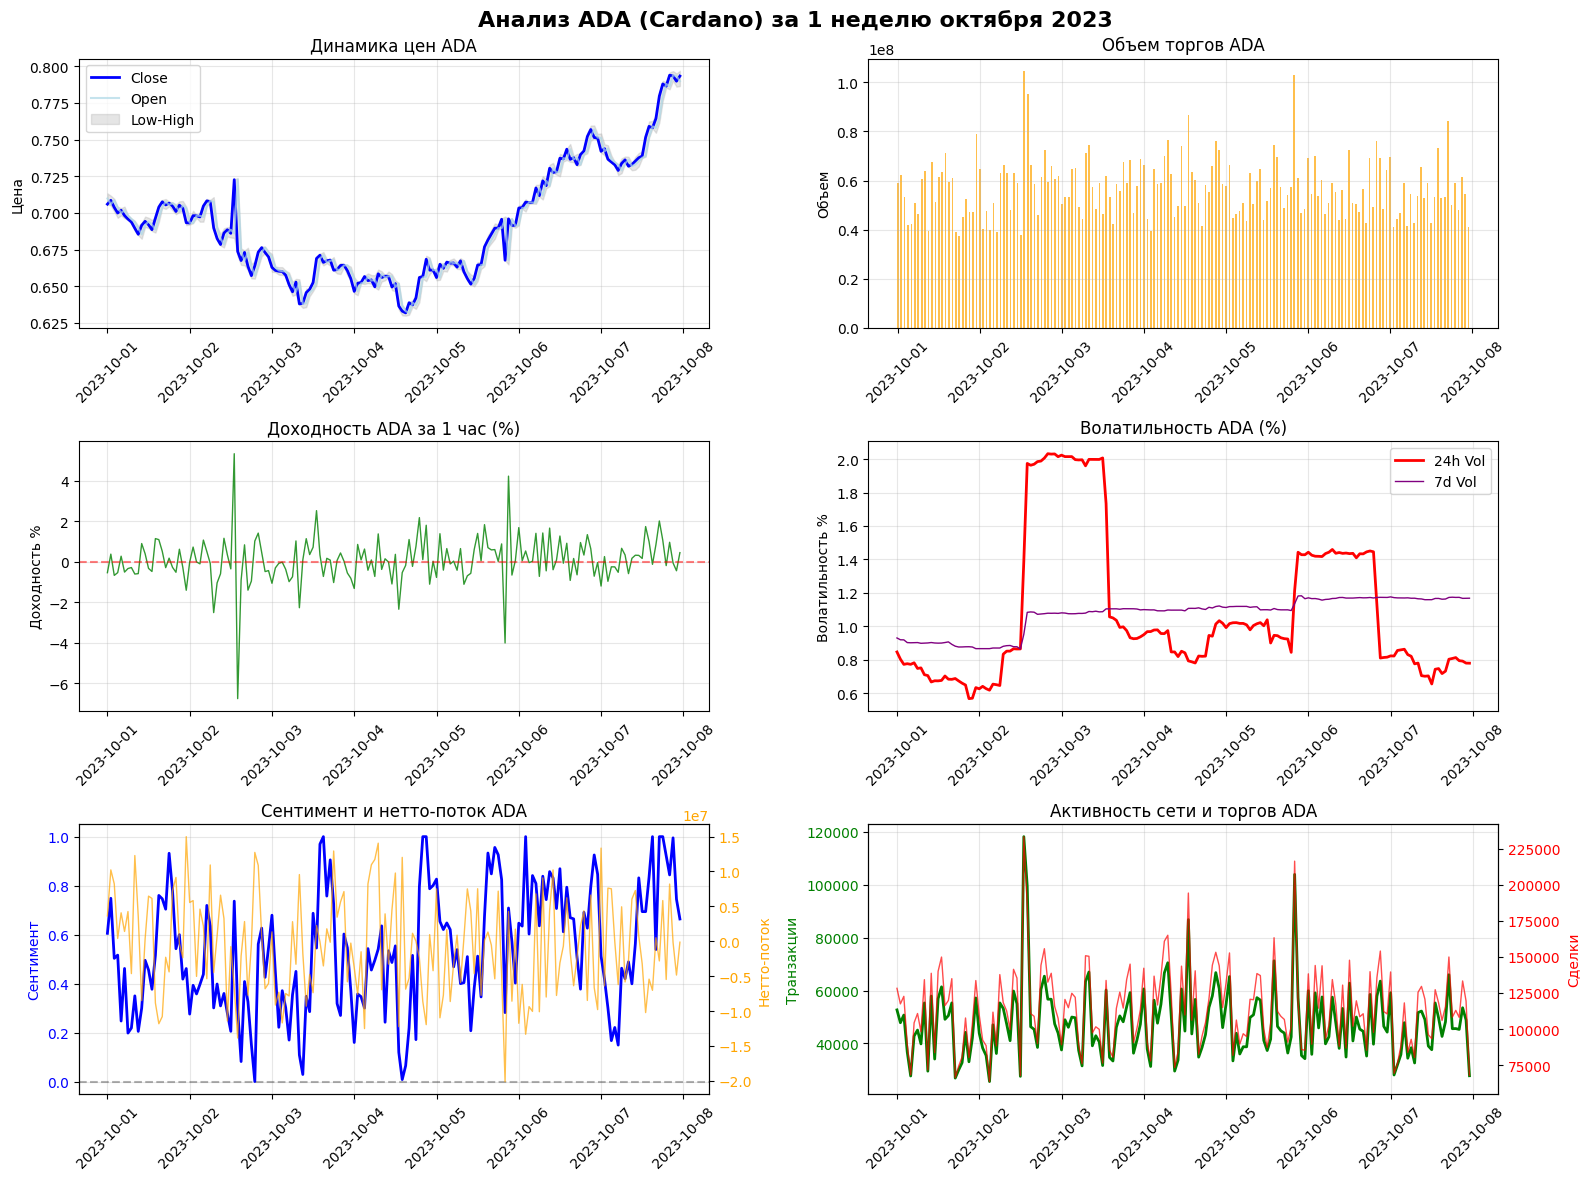


📊 Детальная статистика ADA за неделю:
• Датафрейм от 2023-10-01 00:00:00 до 2023-10-07 23:00:00
• Средняя цена закрытия: 0.6926
• Изменение цены за неделю: 12.37%
• Максимальная доходность за час: 5.33%
• Минимальная доходность за час: -6.77%
• Средний объем: 57114594
• Средний сентимент: 0.539
• Всего транзакций в блокчейне: 8,025,176


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Фильтруем данные за 1 неделю октября 2023 для ADA
ada_week = df[(df['timestamp'] >= '2023-10-01') &
              (df['timestamp'] < '2023-10-08') &
              (df['asset'] == 'ADA')]

print(f"✅ Данные ADA за неделю: {len(ada_week)} записей")

# Создаем графики
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Анализ ADA (Cardano) за 1 неделю октября 2023', fontsize=16, fontweight='bold')

# Форматируем даты для подписей
dates = pd.to_datetime(ada_week['timestamp'])

# 1. Цены (OHLC)
axes[0, 0].plot(dates, ada_week['close'], label='Close', linewidth=2, color='blue')
axes[0, 0].plot(dates, ada_week['open'], label='Open', alpha=0.7, color='lightblue')
axes[0, 0].fill_between(dates, ada_week['low'], ada_week['high'],
                       alpha=0.2, label='Low-High', color='gray')
axes[0, 0].set_title('Динамика цен ADA')
axes[0, 0].set_ylabel('Цена')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Объем торгов
axes[0, 1].bar(dates, ada_week['volume'], alpha=0.7, color='orange', width=0.02)
axes[0, 1].set_title('Объем торгов ADA')
axes[0, 1].set_ylabel('Объем')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Доходность за 1 час
axes[1, 0].plot(dates, ada_week['returns_1h'] * 100, color='green', alpha=0.8, linewidth=1)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Доходность ADA за 1 час (%)')
axes[1, 0].set_ylabel('Доходность %')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Волатильность
axes[1, 1].plot(dates, ada_week['rolling_vol_24h'] * 100, label='24h Vol', color='red', linewidth=2)
axes[1, 1].plot(dates, ada_week['rolling_vol_7d'] * 100, label='7d Vol', color='purple', linewidth=1)
axes[1, 1].set_title('Волатильность ADA (%)')
axes[1, 1].set_ylabel('Волатильность %')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Сентимент и нетто-поток
ax5 = axes[2, 0]
ax5.plot(dates, ada_week['sentiment'], color='blue', label='Сентимент', linewidth=2)
ax5.set_ylabel('Сентимент', color='blue')
ax5.tick_params(axis='y', labelcolor='blue')
ax5.axhline(y=0, color='black', linestyle='--', alpha=0.3)

ax5_2 = ax5.twinx()
ax5_2.plot(dates, ada_week['exchange_net_flow'], color='orange',
          label='Нетто-поток', alpha=0.7, linewidth=1)
ax5_2.set_ylabel('Нетто-поток', color='orange')
ax5_2.tick_params(axis='y', labelcolor='orange')
ax5.set_title('Сентимент и нетто-поток ADA')
ax5.tick_params(axis='x', rotation=45)

# 6. Активность сети и торгов
ax6 = axes[2, 1]
ax6.plot(dates, ada_week['onchain_tx_count'], color='green',
        label='Транзакции в блокчейне', linewidth=2)
ax6.set_ylabel('Транзакции', color='green')
ax6.tick_params(axis='y', labelcolor='green')

ax6_2 = ax6.twinx()
ax6_2.plot(dates, ada_week['num_trades'], color='red',
          label='Количество сделок', alpha=0.7, linewidth=1)
ax6_2.set_ylabel('Сделки', color='red')
ax6_2.tick_params(axis='y', labelcolor='red')
ax6.set_title('Активность сети и торгов ADA')
ax6.tick_params(axis='x', rotation=45)

# Добавляем сетку на все графики
for i in range(3):
    for j in range(2):
        axes[i, j].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Детальная статистика
print(f"\n📊 Детальная статистика ADA за неделю:")
print(f"• Датафрейм от {ada_week['timestamp'].min()} до {ada_week['timestamp'].max()}")
print(f"• Средняя цена закрытия: {ada_week['close'].mean():.4f}")
print(f"• Изменение цены за неделю: {((ada_week['close'].iloc[-1] / ada_week['close'].iloc[0]) - 1) * 100:.2f}%")
print(f"• Максимальная доходность за час: {ada_week['returns_1h'].max() * 100:.2f}%")
print(f"• Минимальная доходность за час: {ada_week['returns_1h'].min() * 100:.2f}%")
print(f"• Средний объем: {ada_week['volume'].mean():.0f}")
print(f"• Средний сентимент: {ada_week['sentiment'].mean():.3f}")
print(f"• Всего транзакций в блокчейне: {ada_week['onchain_tx_count'].sum():,}")

Предварительная обработка данных:

In [15]:
# Обрезаем датафрейм до нужной недели и криптовалюты "ADA", убираем future_return поля
ada_week_clean = df[
    (df['timestamp'] >= '2023-10-01') &
    (df['timestamp'] < '2023-10-08') &
    (df['asset'] == 'ADA')  # ← вот этот фильтр оставляет только ADA
].drop(columns=['future_return_1h', 'future_return_24h'])

print("📊 Статус данных после очистки:")
print(f"Размер датафрейма: {ada_week_clean.shape}")
print(f"Период: {ada_week_clean['timestamp'].min()} до {ada_week_clean['timestamp'].max()}")
print(f"Криптовалюты в данных: {ada_week_clean['asset'].unique()}")  # ← Проверяем какие криптовалюты остались
print(f"Количество уникальных активов: {ada_week_clean['asset'].nunique()}")

# Анализ пропущенных значений
print("\n🔍 Анализ пропущенных значений:")
missing_data = ada_week_clean.isnull().sum()
missing_percent = (ada_week_clean.isnull().sum() / len(ada_week_clean)) * 100
missing_info = pd.DataFrame({
    'Пропущено': missing_data,
    'Процент %': missing_percent
})
print(missing_info[missing_info['Пропущено'] > 0])

# Показываем информацию о данных
print(f"\n📈 Всего записей: {len(ada_week_clean)}")
print(f"Ожидаемо записей за неделю (24ч × 7д): 168")
print(f"Полнота данных: {len(ada_week_clean)/168*100:.1f}%")

📊 Статус данных после очистки:
Размер датафрейма: (168, 15)
Период: 2023-10-01 00:00:00 до 2023-10-07 23:00:00
Криптовалюты в данных: ['ADA']
Количество уникальных активов: 1

🔍 Анализ пропущенных значений:
Empty DataFrame
Columns: [Пропущено, Процент %]
Index: []

📈 Всего записей: 168
Ожидаемо записей за неделю (24ч × 7д): 168
Полнота данных: 100.0%


In [17]:
# Заполнение пропусков для разных типов данных
ada_week_filled = ada_week_clean.copy()

print("🔍 Начальная проверка данных:")
initial_missing = ada_week_filled.isnull().sum().sum()
print(f"Пропусков до заполнения: {initial_missing}")

if initial_missing == 0:
    print("✅ Пропусков нет! Проверяем дубликаты...")

    # Проверка полных дубликатов
    full_duplicates = ada_week_filled.duplicated().sum()
    print(f"Полных дубликатов: {full_duplicates}")

    # Проверка дубликатов по временной метке (должны быть уникальными)
    time_duplicates = ada_week_filled.duplicated(subset=['timestamp']).sum()
    print(f"Дубликатов по времени: {time_duplicates}")

    if full_duplicates > 0:
        print("🗑️ Удаляем полные дубликаты...")
        ada_week_filled = ada_week_filled.drop_duplicates()
        print(f"Осталось записей: {len(ada_week_filled)}")

    if time_duplicates > 0:
        print("⚠️ Внимание: есть дубликаты временных меток!")
        # Оставляем последнюю запись для каждого дубликата времени
        ada_week_filled = ada_week_filled.drop_duplicates(subset=['timestamp'], keep='last')
        print(f"Осталось уникальных временных меток: {len(ada_week_filled)}")

    print("🎯 Данные готовы к анализу!")

else:
    print("🔄 Заполняем пропущенные значения...")

    # Для ценовых данных и объемов - линейная интерполяция
    price_volume_cols = ['open', 'high', 'low', 'close', 'volume', 'spread']
    ada_week_filled[price_volume_cols] = ada_week_filled[price_volume_cols].interpolate(method='linear')

    # Для производных показателей (волатильность, доходность) - forward fill
    derivative_cols = ['returns_1h', 'rolling_vol_24h', 'rolling_vol_7d']
    ada_week_filled[derivative_cols] = ada_week_filled[derivative_cols].fillna(method='ffill')

    # Для счетчиков и потоков - заполнение медианой или 0
    count_flow_cols = ['num_trades', 'onchain_tx_count', 'exchange_net_flow']
    ada_week_filled[count_flow_cols] = ada_week_filled[count_flow_cols].fillna(0)

    # Для сентимента - заполнение средним значением
    ada_week_filled['sentiment'] = ada_week_filled['sentiment'].fillna(ada_week_filled['sentiment'].mean())

    # Если остались пропуски после интерполяции - заполняем forward/backward
    ada_week_filled = ada_week_filled.fillna(method='ffill').fillna(method='bfill')

    # Финальная проверка
    final_missing = ada_week_filled.isnull().sum().sum()
    print("✅ Заполнение завершено!")
    print(f"Осталось пропусков: {final_missing}")

    if final_missing == 0:
        print("🎉 Все пропуски успешно заполнены!")
    else:
        print("⚠️ Остались некоторые пропуски. Возможно, нужен дополнительный анализ.")

# Итоговая информация
print(f"\n📊 Итоговый размер данных: {ada_week_filled.shape}")
print(f"📅 Период: {ada_week_filled['timestamp'].min()} до {ada_week_filled['timestamp'].max()}")

🔍 Начальная проверка данных:
Пропусков до заполнения: 0
✅ Пропусков нет! Проверяем дубликаты...
Полных дубликатов: 0
Дубликатов по времени: 0
🎯 Данные готовы к анализу!

📊 Итоговый размер данных: (168, 15)
📅 Период: 2023-10-01 00:00:00 до 2023-10-07 23:00:00
